In [50]:
# ICVul
import pandas as pd

df_vuln = pd.read_csv('../data/intermediate/churn_icvul.csv')

df_vuln['lines_added'] = df_vuln['lines_added']
df_vuln['lines_removed'] = df_vuln['lines_removed']
df_vuln['lines_modified'] = df_vuln['lines_modified']

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
stats = df_vuln.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Vulnerability Statistics (ICVul):")
print(stats.round(2))

Vulnerability Statistics (ICVul):
            lines_added                lines_removed               \
                 median     mean count        median   mean count   
commit_role                                                         
VFC                 4.0    11.74   314           0.0  23.03   314   
VIC                25.0  1011.55   649           1.0  83.37   649   

            lines_modified                
                    median    mean count  
commit_role                               
VFC                    1.0    5.29   314  
VIC                   11.0  310.07   649  


In [51]:
# KFC (Linux)
import pandas as pd

df_churn = pd.read_csv('../data/intermediate/churn_linux.csv')
df_labels = pd.read_csv('../data/intermediate/commits_dataset_linux.csv')

df_bug = pd.merge(df_labels, df_churn, on='commit_id', how='inner')

df_bug['lines_added'] = df_bug['num_lines_added']
df_bug['lines_removed'] = df_bug['num_lines_deleted']
df_bug['lines_modified'] = df_bug['num_lines_modified']

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
stats = df_bug.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Bug Statistics (Linux KFC):")
print(stats.round(2))

files_stats = df_bug.groupby('commit_role')['files_changed'].mean()
print("\nAverage Files Changed:")
print(files_stats)

Bug Statistics (Linux KFC):
            lines_added               lines_removed               \
                 median    mean count        median   mean count   
commit_role                                                        
BFC                 1.0    5.52  4455           0.0   2.53  4455   
BIC                33.0  221.43  4593           0.0  30.76  4593   

            lines_modified               
                    median   mean count  
commit_role                              
BFC                    1.0   2.97  4455  
BIC                    3.0  15.38  4593  

Average Files Changed:
commit_role
BFC    1.250730
BIC    3.286741
Name: files_changed, dtype: float64


In [52]:
# TOSEM
import pandas as pd

df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem.csv')

metrics = ['lines_added', 'lines_removed', 'lines_modified']
vuln_stats = df_vuln_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Java Vulnerability Statistics (Manual TOSEM):")
print(vuln_stats.round(2))

df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

Java Vulnerability Statistics (Manual TOSEM):
            lines_added                 lines_removed                \
                 median      mean count        median    mean count   
commit_role                                                           
VFC                15.0     87.50   177           0.0   33.65   177   
VIC               217.5  15053.17    94           0.5  638.37    94   

            lines_modified               
                    median   mean count  
commit_role                              
VFC                    4.0  12.52   177  
VIC                    7.5  55.41    94  


In [53]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache.csv')

df_bug_java['lines_added'] = df_bug_java['lines_added']
df_bug_java['lines_removed'] = df_bug_java['lines_deleted']
df_bug_java['lines_modified'] = df_bug_java['lines_modified']

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
stats = df_bug_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Bug Statistics (DS_APACHE):")
print(stats.round(2))

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

files_stats = df_bug_java.groupby('commit_role')['files_changed'].mean()
print("\nAverage Files Changed:")
print(files_stats)

Bug Statistics (DS_APACHE):
            lines_added               lines_removed               \
                 median    mean count        median   mean count   
commit_role                                                        
BFC                 4.0   20.65   198           0.0   8.63   198   
BIC                44.0  275.40   285           4.0  71.98   285   

            lines_modified               
                    median   mean count  
commit_role                              
BFC                    4.0  11.06   198  
BIC                   13.0  67.12   285  

Average Files Changed:
commit_role
BFC    1.954545
BIC    9.547368
Name: files_changed, dtype: float64


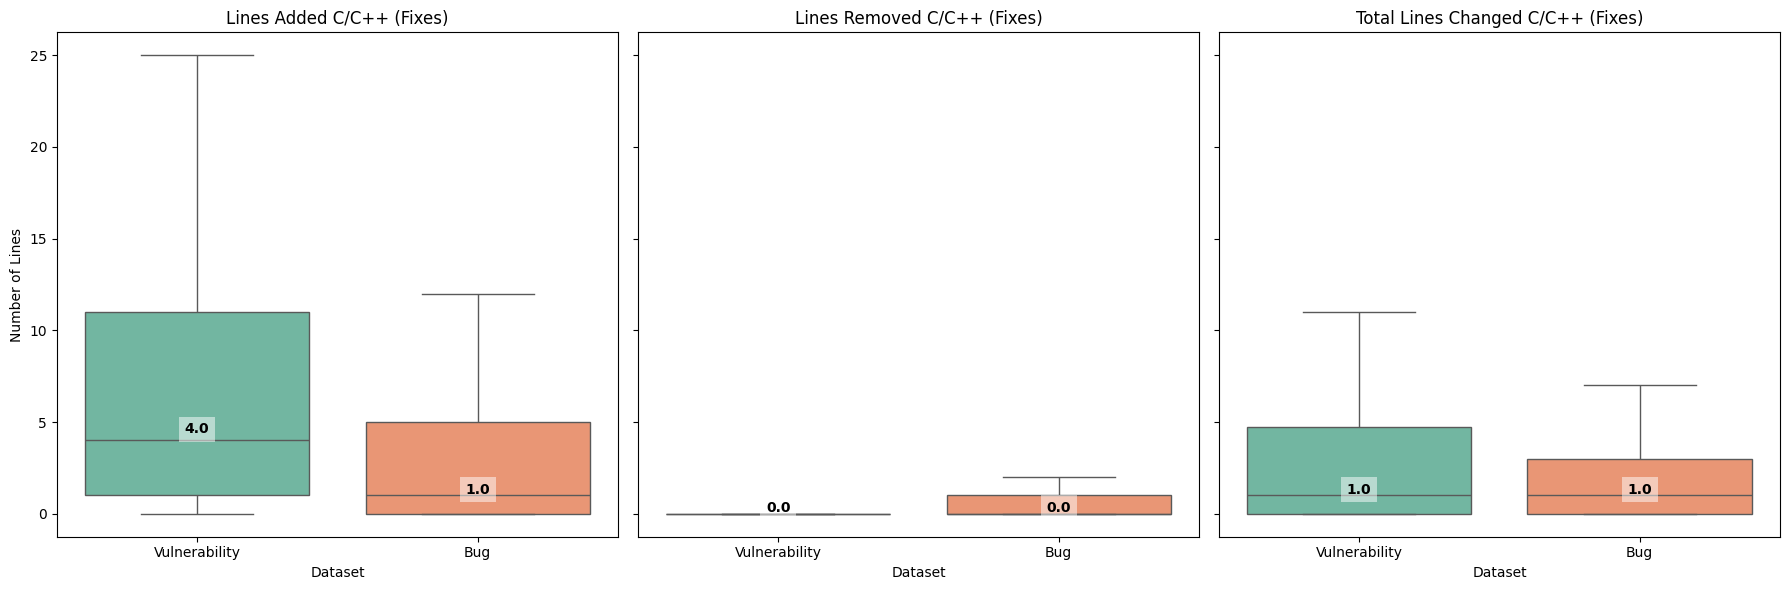

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Fixes)', 'Lines Removed C/C++ (Fixes)', 'Total Lines Changed C/C++ (Fixes)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'{m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

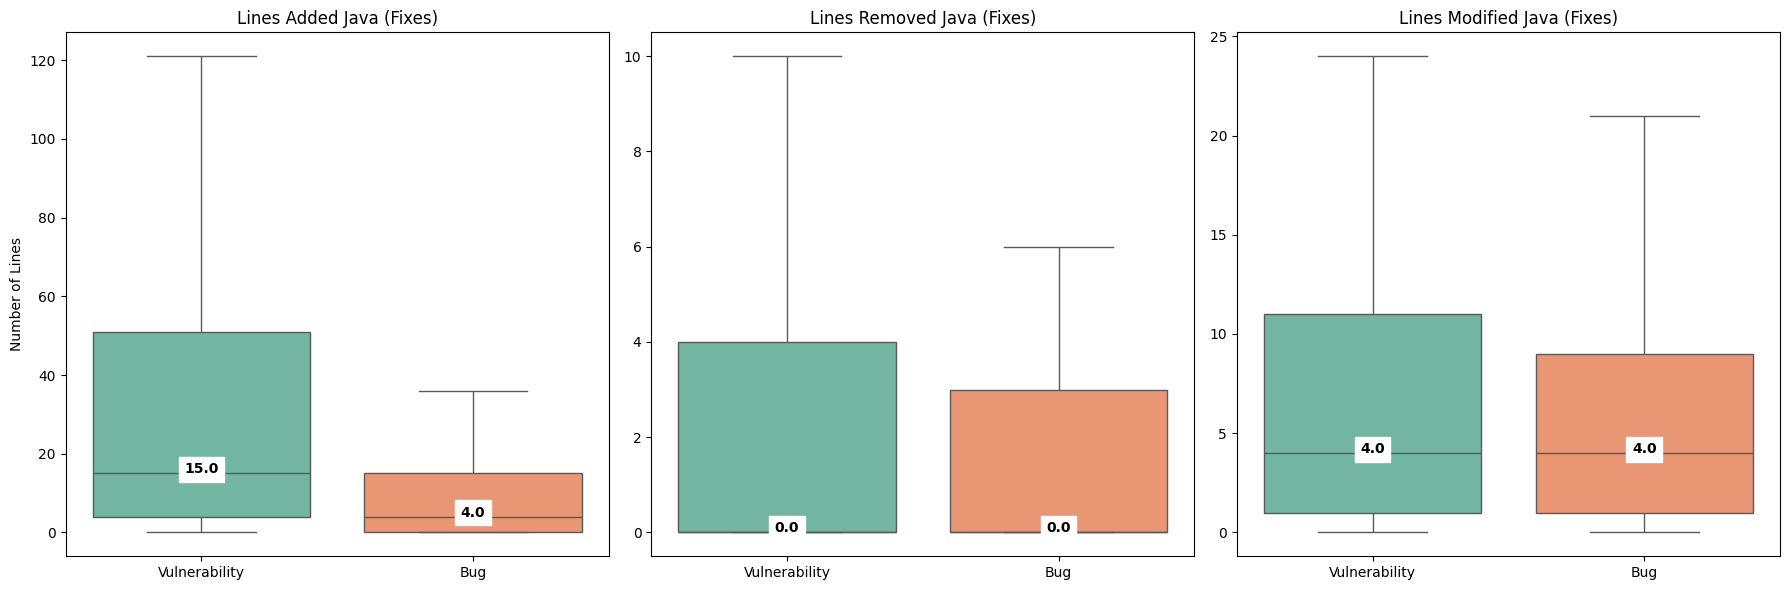

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Fixes)', 'Lines Removed Java (Fixes)', 'Lines Modified Java (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'{m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

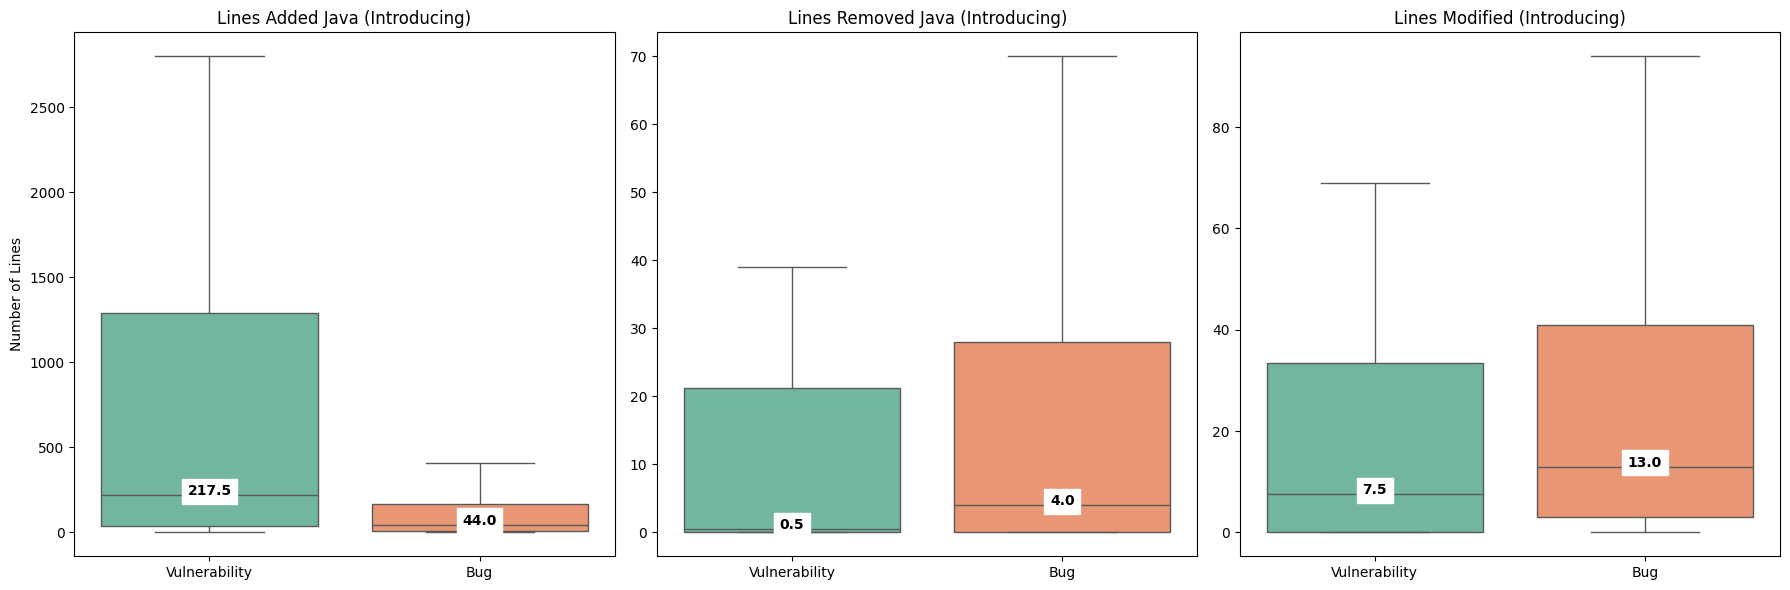

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vic_only.copy()
df_b = df_java_bic_only.copy()

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Introducing)', 'Lines Removed Java (Introducing)', 'Lines Modified (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'{m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()